<a href="https://colab.research.google.com/github/NazHub1993/ML_Notebooks/blob/main/PCA_The_Heal_of_Dimensionality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
from sklearn.datasets import load_digits
dataset=load_digits()
dataset


{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [16]:
df=pd.DataFrame(dataset.data,columns=dataset.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()



In [18]:
df.isna().sum()

,0
pixel_0_0,0
pixel_0_1,0
pixel_0_2,0
pixel_0_3,0
pixel_0_4,0
...,...
pixel_7_3,0
pixel_7_4,0
pixel_7_5,0
pixel_7_6,0


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df,dataset.target,test_size=0.2)

In [20]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [21]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [22]:
model.score(x_test_scaled,y_test)

0.975

#!!!Good Score. Now let's apply PCA

In [23]:
from sklearn.decomposition import PCA
pca=PCA()
pca.fit_transform(x_train_scaled)
pca.transform(x_test_scaled)

array([[-3.43583911e+00, -1.05483055e+00,  2.38886496e+00, ...,
         0.00000000e+00,  6.78603682e-17,  5.89958737e-16],
       [ 1.50948568e+00, -8.76744283e-01,  4.15382772e+00, ...,
         0.00000000e+00, -3.39313157e-16,  1.40994200e-15],
       [-6.75008047e-01,  2.57854632e+00,  1.54442579e+00, ...,
         0.00000000e+00, -2.41368153e-17,  1.03621072e-15],
       ...,
       [-1.77922002e+00, -2.33576212e+00, -2.84739166e+00, ...,
         0.00000000e+00,  5.66519439e-17, -3.39961989e-16],
       [-2.04379011e+00,  3.37600047e+00, -2.88359357e-01, ...,
         0.00000000e+00,  3.65377852e-16,  2.92845804e-15],
       [-2.04227997e+00, -3.57062149e+00, -1.89433984e-02, ...,
         0.00000000e+00, -3.50553774e-16, -1.21990820e-15]])

In [26]:
# Apply PCA to training and test data and store the results
pca = PCA(n_components=None) # Start with all components to analyze explained variance
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Shape of x_train after PCA:", x_train_pca.shape)
print("Shape of x_test after PCA:", x_test_pca.shape)


Shape of x_train after PCA: (1437, 64)
Shape of x_test after PCA: (360, 64)


By default, `PCA()` without specifying `n_components` keeps all principal components (which is 64 in this case, same as the original number of features). This allows us to inspect the `explained_variance_ratio_` to decide on an optimal number of components.

Let's plot the explained variance ratio to determine how many components we might want to keep.

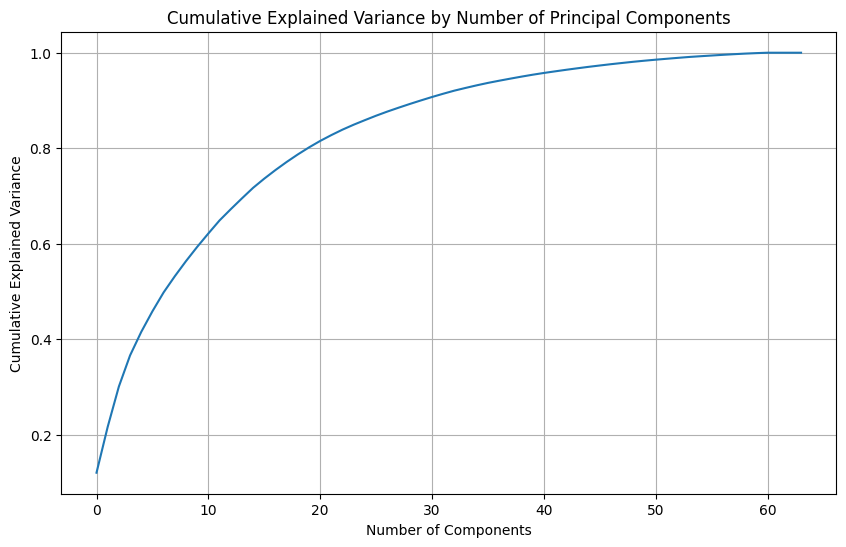

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.grid(True)
plt.show()

# You can also look at the individual explained variance ratios
# print('Individual explained variance ratios:\n', pca.explained_variance_ratio_[:10]) # Display first 10


From the plot, we can see how many components explain a significant portion of the variance. Let's try retraining the Logistic Regression model with a reduced number of components, for example, 95% of the variance explained, or a fixed number of components (e.g., 20 or 30) and compare the performance.

Let's choose `n_components` to explain 95% of the variance.

In [28]:
pca_optimized = PCA(0.95) # Keep components that explain 95% of the variance
x_train_pca_opt = pca_optimized.fit_transform(x_train_scaled)
x_test_pca_opt = pca_optimized.transform(x_test_scaled)

print(f"Number of components chosen to explain 95% variance: {pca_optimized.n_components_}")

# Retrain the Logistic Regression model with PCA-transformed data
model_pca = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model_pca.fit(x_train_pca_opt, y_train)

# Evaluate the model with PCA
score_pca = model_pca.score(x_test_pca_opt, y_test)
print(f"Model accuracy with PCA (95% variance): {score_pca}")

# Compare with the previous score without PCA
# The previous score was {model.score(x_test_scaled, y_test)} (retrieved from the notebook state)
print(f"Model accuracy without PCA: {0.975}")


Number of components chosen to explain 95% variance: 40
Model accuracy with PCA (95% variance): 0.9611111111111111
Model accuracy without PCA: 0.975
